**Explanation**

## Bipartite Ranking Algorithm
This notebook implements a bipartite ranking algorithm that ranks items based on user ratings while iteratively refining user reputations. The goal is to achieve a fair ranking system where user biases are minimized.

### **How it Works**
1. **Initialize User Reputation**: All users start with equal reputation.
2. **Compute Item Rankings**: Item scores are calculated using weighted user ratings.
3. **Update User Reputation**: Users with large rating errors are penalized.
4. **Iterate Until Convergence**: The process is repeated until rankings stabilize.

This notebook will:
- Load the dataset.
- Apply the bipartite ranking algorithm.
- Visualize the resulting item rankings.




**1.    Imports**

In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

**2.    Load Dataset**

In [43]:
file_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/goodreads_reviews_spoiler.json"  # Replace with your dataset path

# Load dataset
with open(file_path, 'r') as f:
    data = [json.loads(line) for line in f]
df = pd.DataFrame(data)

# Get unique users and items
users = df["user_id"].unique()
items = df["book_id"].unique()

# Normalize the 'overall' column to range [0, 1]
min_rating = 0
max_rating = 5
print(df["rating"].min(), df["rating"].max())

df["normalizedOverall"] = (df["rating"] - min_rating + 1) / (max_rating - min_rating + 1)

num_unique_items = df["user_id"].nunique()
num_unique_users = df["book_id"].nunique()
num_normalized_ratings = df["normalizedOverall"].notnull().sum()

print(f"Number of unique items (asin): {num_unique_items}")
print(f"Number of unique users (reviewerID): {num_unique_users}")
print(f"Total number of normalized ratings: {num_normalized_ratings}")

0 5
Number of unique items (asin): 18892
Number of unique users (reviewerID): 25475
Total number of normalized ratings: 1378033


**3.    Bipartite Ranking Algorithm**

In [28]:
def bipartite_ranking_algorithm(df, lambda_factor=0.5, max_iter=7):
    """
    Bipartite ranking algorithm with fixed 7 iterations and lambda_factor=0.5.
    Ignores convergence check.
    """
    users = df["user_id"].unique()
    items = df["book_id"].unique()

    # Preprocess: Group ratings by item and user
    item_to_ratings = dict(tuple(df.groupby("book_id")))
    user_to_ratings = dict(tuple(df.groupby("user_id")))

    # Initialize user reputations
    user_reputation = {user: 1.0 for user in users}

    for _ in range(max_iter):  # fixed 7 iterations
        # Step 1: Update item rankings
        item_rankings = {}
        for item in items:
            if item not in item_to_ratings:
                continue

            item_ratings = item_to_ratings[item]
            users_who_rated = item_ratings["user_id"].values
            ratings = item_ratings["normalizedOverall"].values

            if len(users_who_rated) == 0:
                continue

            weighted_sum = sum(
                float(user_reputation[u]) * float(r)
                for u, r in zip(users_who_rated, ratings)
            )
            total_weight = len(users_who_rated)

            if item == '11870085':
                avg_rating = sum(ratings) / len(ratings)
                avg_user_rep = sum(user_reputation[u] for u in users_who_rated) / len(users_who_rated)
                print(f"Item {item} - Weighted Sum: {weighted_sum}, Total Weight: {total_weight}")
                print(f"Item {item} - Avg Rating: {avg_rating:.4f}, Avg User Reputation: {avg_user_rep:.4f}")

            item_rankings[item] = weighted_sum / total_weight if total_weight > 0 else 0

        # Step 2: Update user reputations
        for user in users:
            if user not in user_to_ratings:
                continue

            user_ratings = user_to_ratings[user]
            items_rated = user_ratings["book_id"].values
            ratings = user_ratings["normalizedOverall"].values

            if len(items_rated) == 0:
                continue

            rating_errors = [
                abs(r - item_rankings[i]) for i, r in zip(items_rated, ratings)
                if i in item_rankings
            ]
            if not rating_errors:
                continue

            avg_error = sum(rating_errors) / len(rating_errors)
            user_reputation[user] = max(1 - lambda_factor * avg_error, 0)

    return item_rankings, user_reputation


**4. Compute Item Rankings**


In [23]:
# Compute rankings using the bipartite ranking algorithm
rankings, userReputation = bipartite_ranking_algorithm(df)

print(rankings)



Item 11870085 - Weighted Sum: 2396.5, Total Weight: 2745
Item 11870085 - Weighted Sum: 2218.944852131848, Total Weight: 2745
Item 11870085 - Weighted Sum: 2196.5238404599977, Total Weight: 2745
Item 11870085 - Weighted Sum: 2192.8531724279364, Total Weight: 2745
Item 11870085 - Weighted Sum: 2192.215734007301, Total Weight: 2745
Item 11870085 - Weighted Sum: 2192.1022482577755, Total Weight: 2745
Item 11870085 - Weighted Sum: 2192.081741494067, Total Weight: 2745
{'18245960': 0.7059472872595426, '16981': 0.6844922797857459, '28684704': 0.792121014828074, '27161156': 0.6867708903445927, '25884323': 0.705339820972184, '19398490': 0.7937653805988757, '22318578': 0.6710167539765317, '24189224': 0.5875541692797785, '22551730': 0.7566484678819437, '22816087': 0.687328361827719, '5577844': 0.7099600588782015, '21792828': 0.7543354908633915, '17855756': 0.7686536903947901, '16158596': 0.7231903469117172, '12961964': 0.743307582788601, '17315048': 0.7975117951040553, '17860739': 0.7046270156823

In [9]:
print(userReputation)

{'8842281e1d1347389f2ab93d60773d4d': 0.8930172969247393, '01ec1a320ffded6b2dd47833f2c8e4fb': 0.9128249200865092, '83d6e6f80d7c32c6676b3ab3b01543cd': 0.9218987798135401, '2f6af21d14c83a5df6cdcef5e6af0b3e': 0.915023412307655, '8e1db93d364acf3893ce998ebb8d57fc': 0.9365147544069026, '4672eb229c808b792b8ea95f01f19784': 0.9075976656772775, '0757e6c8076682b47d9d4dcebb6db776': 0.9361386973044572, '3682faa64cbddd0ef719d4a539d6ac51': 0.8887253875740011, '34216df2a5f3846b17e3f96bea6c2ad7': 0.9095602094597951, '5f550cc8d90df1759eda1496621187d8': 0.926900116495373, '1761847f29b18dd5f1afe7215f32f3b2': 0.9026236177122307, '5e7d7bf79b985bd5a1c0223a59ba96be': 0.941794480458992, '2ab7623f60197f5b674dff11db90911f': 0.9187701602278324, '74e64584ec45d82d546a42eb235ade97': 0.9829159314147449, '4f1f7a262da80b17d21ae600bb61ec1b': 0.9099923324685354, '23be2c07c1dd24c557aaa7c42c5cfd03': 0.9288656271957132, 'eadf8c06370d9c6fd74121723c8d20e3': 0.9193217906238603, 'c4b5fd2c733469fc3e83e86ccfd6ce37': 0.901367069275

**5. Visualizing the Distribution of Item Rankings**

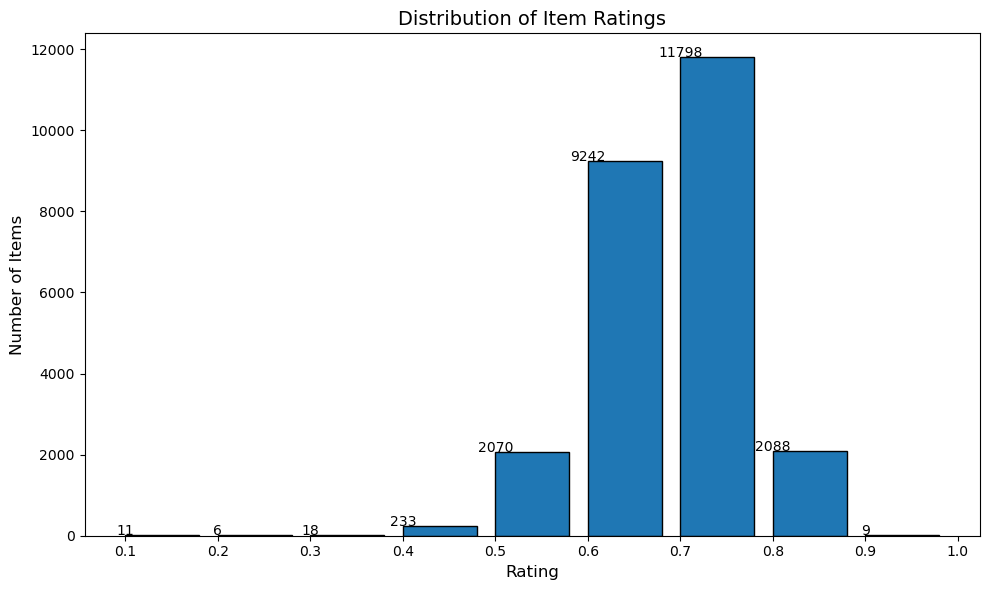

In [5]:
# Extract the ratings from the rankings
ratings = list(rankings.values())

# Define bins for the ratings (from 0.1 to 1.0 with steps of 0.1)
bins = np.arange(0.1, 1.1, 0.1)

# Count how many items fall into each rating bin
hist, bin_edges = np.histogram(ratings, bins=bins)

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], hist, width=0.08, align='edge', edgecolor='black')

# Adding numbers on top of bars
for i in range(len(hist)):
    plt.text(bin_edges[i], hist[i] + 1, str(hist[i]), ha='center', fontsize=10)

# Finalize the plot
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.title('Distribution of Item Ratings', fontsize=14)
plt.xticks(bins)  # Ensure the x-ticks correspond to the rating bins
plt.tight_layout()
plt.show()


**6. Metrics**


**6.1   Effectiveness**

In [6]:
def compute_aggregated_average_ranking(df):
    return df.groupby("book_id")["normalizedOverall"].mean().to_dict()

def compute_kendall_tau(ranking_1, ranking_2):
    common_items = set(ranking_1.keys()) & set(ranking_2.keys())  # Ensure only common items are compared
    
    if len(common_items) < 2:  # Need at least two rankings to compute Kendall's tau
        return 0
    
    sorted_items = sorted(common_items)  # Sort items to ensure consistent order
    
    list_1 = [ranking_1[item] for item in sorted_items]
    list_2 = [ranking_2[item] for item in sorted_items]
    
    return kendalltau(list_1, list_2).correlation

# Compute the aggregated average ranking
aa_rankings = compute_aggregated_average_ranking(df)

# Compute Kendall’s tau for the entire dataset
tau_value = compute_kendall_tau(rankings, aa_rankings)
print(f"Kendall’s τ: {tau_value:.4f}")



Kendall’s τ: 0.9597


**6.2   Robustness**

In [7]:
import os
import time
import json
import pandas as pd

# Directory where your spam-injected files are located
spam_dir = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/spam_versions_goodreads2"

# Spam ratios you want to evaluate
ratios = [10, 30, 50, 70]
i = 0

while i < len(ratios):
    start_time = time.time()
    
    percent = ratios[i]
    file_name = f"reviews_with_{percent}percent_spam.json"
    file_path = os.path.join(spam_dir, file_name)

    # Load the dataset
    with open(file_path, 'r') as f:
        data = [json.loads(line) for line in f]
    df_attack = pd.DataFrame(data)

    # Get unique users and items
    users = df_attack["user_id"].unique()
    items = df_attack["book_id"].unique()

    print(df_attack["normalizedOverall"].min(), df_attack["normalizedOverall"].max())
    # Normalize the 'rating' column to range [0, 1]
    min_rating = 0
    max_rating = 5
    df_attack["normalizedOverall"] = (df_attack["rating"] - min_rating + 1) / (max_rating - min_rating + 1)
    # Compute rankings using your bipartite ranking algorithm
    rankingsSpam, userReputation = bipartite_ranking_algorithm(df_attack)

    # Compute Kendall's tau
    tau_value = compute_kendall_tau(rankings, rankingsSpam)

    # Measure elapsed time
    elapsed_time = time.time() - start_time

    # Print the result
    print(f"[{percent}% Spam] Kendall’s τ: {tau_value:.4f} | Time: {elapsed_time:.2f} seconds")
    
    i += 1


KeyboardInterrupt: 

**6.3. Bribery Resistance**

In [38]:
import pandas as pd
import os
import json

# === Compute original rankings and seller wealth ===
# original_rankings, _ = bipartite_ranking_algorithm(df)

def compute_wealth(df, item_id, rankings):
    item_id = str(item_id)  # Ensure string type match
    item_ratings = df[df["book_id"] == item_id]
    n_ratings = len(item_ratings)
    avg_score = rankings[item_id]
    print("n_ratings: ", n_ratings)
    print("avg_score: ", avg_score)
    print(f"Book {item_id} — #Ratings: {n_ratings}, Ranking Score: {avg_score}")
    return n_ratings * avg_score


def parse_strategy_cost(txt_path, scale_by_user=False):
    total_cost = 0.0
    user_ids = set()

    with open(txt_path, "r") as f:
        for line in f:
            if "UserID" in line and "Old" in line and "New" in line:
                try:
                    parts = line.strip().split(", ")
                    user_id = parts[0].split(": ")[1]
                    old_val = parts[1].split(": ")[1]
                    new_val = parts[2].split(": ")[1]
                    old = float(old_val) if old_val != "None" else 0.0
                    new = float(new_val) if new_val != "None" else 0.0
                    user_ids.add(user_id)
                    total_cost += abs(new - old)
                except Exception as e:
                    print(f"⚠️ Error parsing line: {line.strip()} → {e}")
    if scale_by_user:
        total_cost *= 1
    return total_cost, user_ids


# === Define target items ===
target_items = [11870085,15897235,23398702]
print(df["book_id"].isin([str(target_items[0])]).sum())
original_wealth = {item: compute_wealth(df, item, rankings) for item in target_items}

print("\n📊 Original Wealth:")
# print(original_wealth)

# === Iterate through each altered dataset ===
base_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/bribery_attack_sets3"
results = []
for item_id in target_items:
    item_folder = os.path.join(base_path, f"item_{item_id}")
    for fname in os.listdir(item_folder):
        if fname.endswith(".json"):
            scenario_name = fname.replace(".json", "")
            full_path_json = os.path.join(item_folder, fname)
            print("full_path_json: ", full_path_json)
            with open(full_path_json, 'r') as f:
                data = [json.loads(line) for line in f]
            df_attack = pd.DataFrame(data)

            min_rating = 0
            max_rating = 5
            df_attack["normalizedOverall"] = (df_attack["rating"] - min_rating + 1) / (max_rating - min_rating + 1)

            txt_path = os.path.join(item_folder, scenario_name + "_changes.txt")
            strategy_cost = 0.0
            scale_by_user = "new" in scenario_name.lower()
            user_ids = set()
            if os.path.exists(txt_path):
                strategy_cost, user_ids = parse_strategy_cost(txt_path, scale_by_user=scale_by_user)
            print(f"Scenario: {scenario_name}, Strategy Cost: {strategy_cost:.2f}")

            # Run ranking algorithm before and after
            original_rankings, userReputation = bipartite_ranking_algorithm(df)
            altered_rankings, userReputationAltered = bipartite_ranking_algorithm(df_attack)

            attacked_wealth = compute_wealth(df_attack, item_id, altered_rankings)

            if "nuke" in scenario_name.lower():
                delta = attacked_wealth - original_wealth[item_id]
            else:
                delta = attacked_wealth - original_wealth[item_id] - strategy_cost

            results.append({
                "ItemID": item_id,
                "Scenario": scenario_name,
                "OriginalWealth": original_wealth[item_id],
                "AttackedWealth": attacked_wealth,
                "StrategyCost": strategy_cost,
                "Delta": delta
            })

            # === Bribed users' reputation ===
            if user_ids:
                totalRep=0
                for i in user_ids:
                    totalRep+=userReputationAltered[i]
                
                bribed_users_average_rep = totalRep/len(user_ids) 
                

# === Convert to DataFrame and display all results ===
results_df = pd.DataFrame(results)
print("\n📋 All Attack Scenarios with Strategy Cost:")
print(results_df.to_string(index=False))

# === Compute total sum of absolute delta per item ===
results_df["AbsDelta"] = results_df["Delta"].abs()
sum_abs_deltas = results_df.groupby("ItemID")["AbsDelta"].sum().reset_index()
sum_abs_deltas.rename(columns={"AbsDelta": "TotalAbsDelta"}, inplace=True)

print("\n📊 Total Sum of |Delta| per Item (Net of Strategy Cost):")
print(sum_abs_deltas.to_string(index=False))


2745
n_ratings:  2745
avg_score:  0.7985725834222467
Book 11870085 — #Ratings: 2745, Ranking Score: 0.7985725834222467
n_ratings:  10
avg_score:  0.6613224980975848
Book 15897235 — #Ratings: 10, Ranking Score: 0.6613224980975848
n_ratings:  25
avg_score:  0.7732884558490808
Book 23398702 — #Ratings: 25, Ranking Score: 0.7732884558490808

📊 Original Wealth:
full_path_json:  /home/martimsbaltazar/Desktop/tese/datasets/goodreads/bribery_attack_sets3/item_11870085/nuke_new_random.json
Scenario: nuke_new_random, Strategy Cost: 45.67
Item 11870085 - Weighted Sum: 2396.5, Total Weight: 2745
Item 11870085 - Avg Rating: 0.8730, Avg User Reputation: 1.0000
Item 11870085 - Weighted Sum: 2218.944852131848, Total Weight: 2745
Item 11870085 - Avg Rating: 0.8730, Avg User Reputation: 0.9249
Item 11870085 - Weighted Sum: 2196.5238404599977, Total Weight: 2745
Item 11870085 - Avg Rating: 0.8730, Avg User Reputation: 0.9163
Item 11870085 - Weighted Sum: 2192.8531724279364, Total Weight: 2745
Item 118700

In [47]:
item = '11870085'
original_avg = df[df['book_id']==item]['normalizedOverall'].mean()

base_path = "/home/martimsbaltazar/Desktop/tese/datasets/goodreads/bribery_attack_sets3/item_11870085/nuke_same_random.json"

with open(base_path, 'r') as f:
    data = [json.loads(line) for line in f]


df_attack = pd.DataFrame(data)

min_rating = 0
max_rating = 5
df_attack["normalizedOverall"] = (df_attack["rating"] - min_rating + 1) / (max_rating - min_rating + 1)

original_avg = df[df['book_id']==item]['normalizedOverall'].mean()
altered_avg = df_attack[df_attack['book_id']==item]['normalizedOverall'].mean()

print(original_avg, altered_avg)




0.8730418943533698 0.8026715239829992


In [ ]:
altered_avg = pd.DataFrame(data)[pd.DataFrame(data)['book_id']==item]['rating'].mean()
print(altered_avg) 0.8159

4.301639344262295
